# Mapping the Potential Destructive Power of Wildfires Using Machine Learning
---
## Module 1: *Data Exploration*
##### Version Number: 3.0
---
### Contents  
> 1. *Weather Data* 
> 2. *Wildfire Data*
> 3. *Mesh Network*
---
### Notes
- Integrate wildfire impact data with daily weather data from extracted from gridMET.
### Inputs
- Daily Weather Readings - `gridmet_final.csv` 
- Wildfire Damage Data - `clean_fires.csv` (cleaned in module 1)
- California Mesh Sampling Grid - `sampling_points.csv` (built in appendix A) 
---
### Outputs  
- `model_fire_pop_income.csv` Cleaned weather dataset merged with fire damage severity, population and mean income data
---
### User Created Dependencies  

In [1]:
import os
import sys

# Allow import of custom modules from the parent directory
sys.path.append(os.path.abspath(os.path.join('..')))

# Show basic facts about a dataframe
from src.data_utils import basic_explore

# basic health checks after a merge
from src.data_utils import post_merge_check

# function to map fire data
from src.plot_utils import plot_fire_damage

---
### Third Party Dependencies

In [14]:
# Data handling
import pandas as pd
import numpy as np
import geopandas as gpd
import datetime as dt

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Point
import matplotlib.ticker as ticker

---

In [3]:
pd.set_option('display.max_colwidth', None)

## 1. Weather Data - `gridmet_final.csv`

> ### Source:
> Weather variables (temperature, precipitation, humidity, etc.) were sourced from gridMET, a high-resolution (~4 km) gridded 
> dataset of daily meteorological data for the contiguous United States.\
> URL: https://www.climatologylab.org/gridmet.html

In [4]:
weather = pd.read_csv('../data/raw/gridmet_final.csv')
weather_meta = pd.read_csv('../data/raw/weather_meta.csv')

In [5]:
weather_meta

,Full Name,Units,Description
0,Daily Maximum Air Temperature,°C,Maximum air temperature at 2 meters above ground (Kelvin)
1,Daily Minimum Air Temperature,°C,Minimum air temperature at 2 meters above ground (Kelvin)
2,Vapor Pressure Deficit,kPa,Difference between saturation vapor pressure and actual vapor pressure (kPa); indicates atmospheric drying power
3,Maximum Relative Humidity,%,Maximum daily relative humidity (%) at 2 meters
4,Minimum Relative Humidity,%,Minimum daily relative humidity (%) at 2 meters
5,Specific Humidity,kg/kg,Mass of water vapor per unit mass of air (kg/kg)
6,Precipitation,mm,Daily total precipitation (mm)
7,Wind Speed,m/s,Daily wind speed (m/s) at 10 meters
8,Solar Radiation,W/m²,Daily incoming shortwave radiation (W/m²)
9,Actual Evapotranspiration,mm,Estimated evapotranspiration from actual vegetation (mm/day)


In [6]:
basic_explore(weather)

Rows:  446340  Columns:  22
Duplicates  0
Total NA values:  0  of  9819480 datapoints


## 2. Wildfire Data - `clean_fires.csv`


Wildfire data was sourced from publically available records from the Cal Fire website. Estimation and cleaning are presented in Appendix B.

Source: [CAL FIRE – Fire Incidents](https://www.fire.ca.gov/)  


- `Date` - Date fire started
- `County` - County fire is located in
- `Fire Name` - Official fire name for California
- `FinalAcres` - Total acres burned per wildfire incident
- `Estimated Damage` - Damages caused by wildfire incidents as estimated in Appendix B
- `Fire_Latitude`,`Fire_Longitude` - Spatial data for wildfire start location

In [7]:
fire_data = pd.read_csv("../data/processed/fire_data.csv")
basic_explore(fire_data)

Rows:  70919  Columns:  7
Duplicates  0
Total NA values:  0  of  496433 datapoints


In [8]:
fire_data

,FinalAcres,Date,Fire_Latitude,Fire_Longitude,County,Fire Name,Estimated Damage
0,0.0,2018-01-01,37.802100,-118.469700,Mono,yellow jacket,0.0
1,0.0,2018-01-01,34.031731,-117.950401,Los Angeles,lac-393275,0.0
2,0.0,2018-01-01,34.682388,-118.085892,Los Angeles,lac-393502,0.0
3,0.0,2018-01-01,33.996208,-117.870201,Los Angeles,lac-000253,0.0
4,0.0,2018-01-01,34.674992,-118.132889,Los Angeles,lac-393386,0.0
...,...,...,...,...,...,...,...
70914,0.0,2025-01-23,34.674870,-118.160690,Los Angeles,lac-030571,0.0
70915,0.0,2025-01-23,33.923190,-118.209760,Los Angeles,lac-030642,0.0
70916,0.0,2025-01-23,34.031560,-118.052350,Los Angeles,lac-030649,0.0
70917,0.0,2025-01-23,34.074640,-117.750170,Los Angeles,lac-030376,0.0


In [9]:
after_total = fire_data['Estimated Damage'].values.sum()
total_fires = len(fire_data[fire_data['Estimated Damage'] > 0])
print(f"Total Estimated Value: ${after_total:,.0f} in {total_fires} wildfires.")

Total Estimated Value: $37,837,554,321 in 496 wildfires.


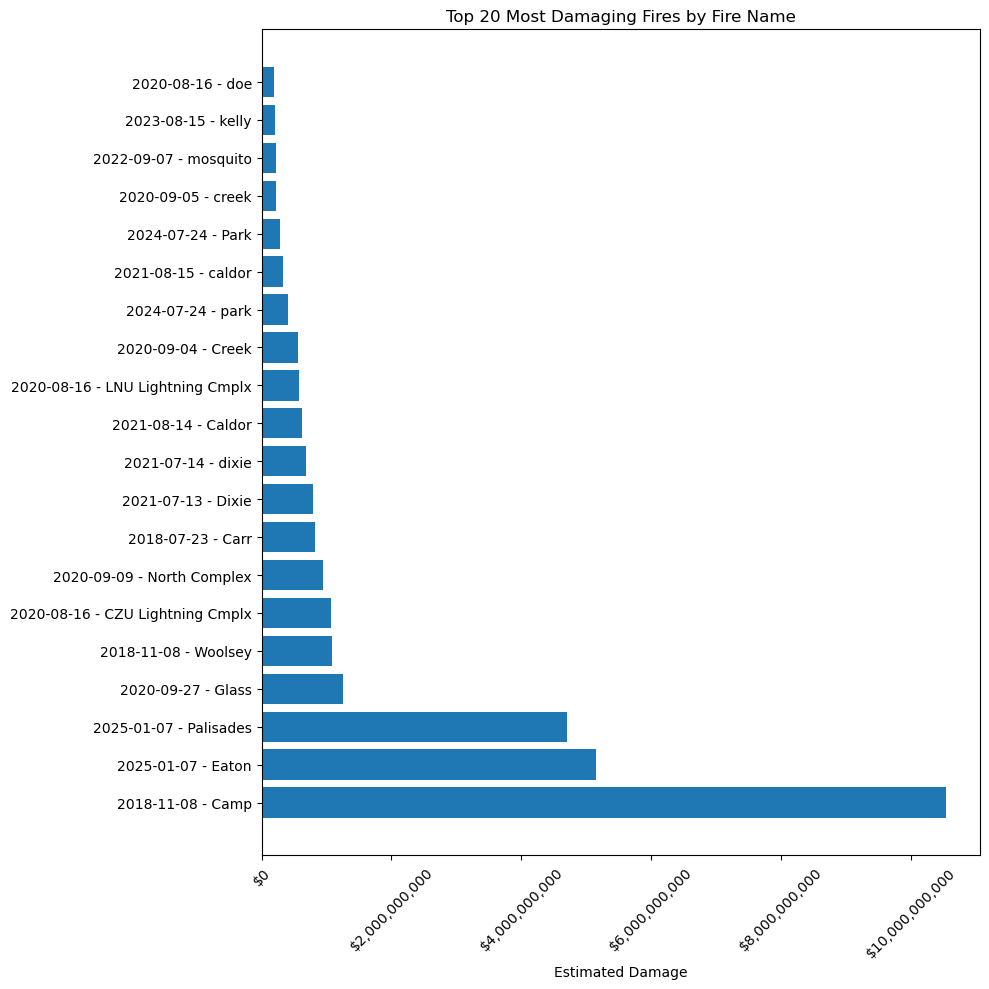

In [15]:
top_days = fire_data.sort_values('Estimated Damage', ascending=False).head(20)
plt.figure(figsize=(10, 10))
plt.barh(top_days['Date'].astype(str) + ' - ' + top_days['Fire Name'], top_days['Estimated Damage'])
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.title("Top 20 Most Damaging Fires by Fire Name")
plt.xlabel("Estimated Damage")
plt.xticks(rotation=45)
plt.tight_layout()

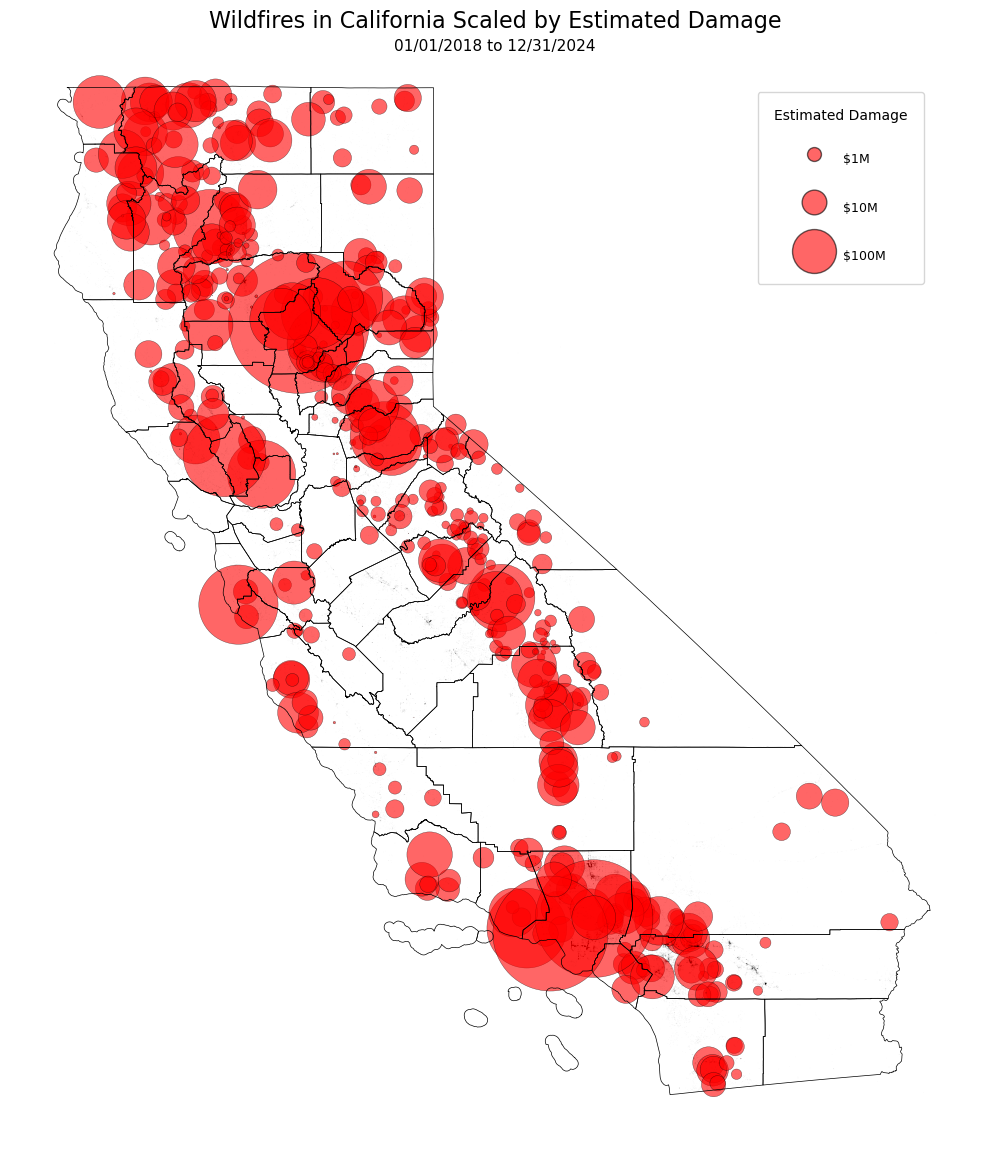

In [10]:
fire_data_gdf = gpd.GeoDataFrame(
    fire_data,
    geometry=gpd.points_from_xy(fire_data['Fire_Longitude'], fire_data['Fire_Latitude']),
    crs='EPSG:4326'
)
plot_fire_damage(fire_data_gdf,'Estimated Damage')

### 3. Load Mesh Network - `sampling_points.csv`

<img src="../data/maps/mesh.jpg" width="600">

In [11]:
## Load file
samples = pd.read_csv("../data/raw/sampling_points.csv")
sample_meta = pd.read_csv("../data/raw/sampling_meta.csv")
sample_meta

,Field Name,Desciption
0,Sample_Longitude,Longitude of sampling point
1,Sample_Latitude,Latitude of sampling point
2,Sample_Elevation,Elevation at sampling point location
3,Region_ID,a unique integer representing each CDFW region in California
4,Region_Name,Name of CDFW region
5,County,County where sampling point is located
6,Interface_Area,Sum of interface zones located in 36Km buffer surrounding sampling point
7,Intermix_Area,Sum of intermix zones located in 36Km buffer surrounding sampling point
8,Influence_Area,Sum of influence zones located in 36Km buffer surrounding sampling point
9,Total_Housing,Sum of housing units located in 36Km buffer surrounding sampling point


In [12]:
basic_explore(samples)

Rows:  173  Columns:  16
Duplicates  0
Total NA values:  0  of  2768 datapoints


---